# Linear Regression on Customer Churn

In [23]:
%pip install -q pandas numpy kagglehub scikit-learn matplotlib seaborn statsmodels


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import statsmodels.api as sm
from kagglehub import KaggleDatasetAdapter
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import linear_reset

## 1. Data Loading and Cleaning

In [25]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
# clean data
# check missing values per column
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [27]:
df.isna().any().any()

np.False_

In [28]:
df.isna().sum().sum()

np.int64(0)

There are no missing values in any column or any rows with missing information. The data is already clean.

In [29]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].unique())

customerID <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection <StringArray>
['No', 'Yes', 'No internet service']
Length: 3,

/var/folders/v_/0vbsz4w56pd0x7dm1l06mldh0000gp/T/ipykernel_24421/2490523665.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
# convert variable types

# convert churn (target col) to 0 or 1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# drop customer id column
df = df.drop(columns=["customerID"])

# convert total charges from string to numeric col
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)



In [32]:
#  multiplelines: combine no/no phone service to 0, and yes to 1
df["MultipleLines"] = df["MultipleLines"].replace({
    "No phone service": "No"
})

# internet features: combine no/no internet service to 0, and yes to 1
internet_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in internet_features:
    df[col] = df[col].replace({
        "No internet service": "No"
    })

# convert binary yes/no to 0,1
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].map({
        "No": 0,
        "Yes": 1
    })

# convert gender to binary
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})

# one hot encode categorical features
categorical_cols = ["Contract",
                    "PaymentMethod",
                    "InternetService"]

df = pd.get_dummies(df, columns = categorical_cols, drop_first=True, dtype=int)

# don't use multiple lines column


In [33]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,0,1,...,84.80,1990.50,0,1,0,0,0,1,0,0
7039,0,0,1,1,72,1,1,0,1,1,...,103.20,7362.90,0,1,0,1,0,0,1,0
7040,0,0,1,1,11,0,0,1,0,0,...,29.60,346.45,0,0,0,0,1,0,0,0
7041,1,1,1,0,4,1,1,0,0,0,...,74.40,306.60,1,0,0,0,0,1,1,0


## 2. Check Assumptions and EDA

In [34]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No'],
      dtype='str')

In [35]:
features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No']
target = 'Churn'

### Linearity Assumption Checks
Test linearity using predictor-vs-response scatter plots, a residuals-vs-fitted plot, and the Ramsey RESET test.

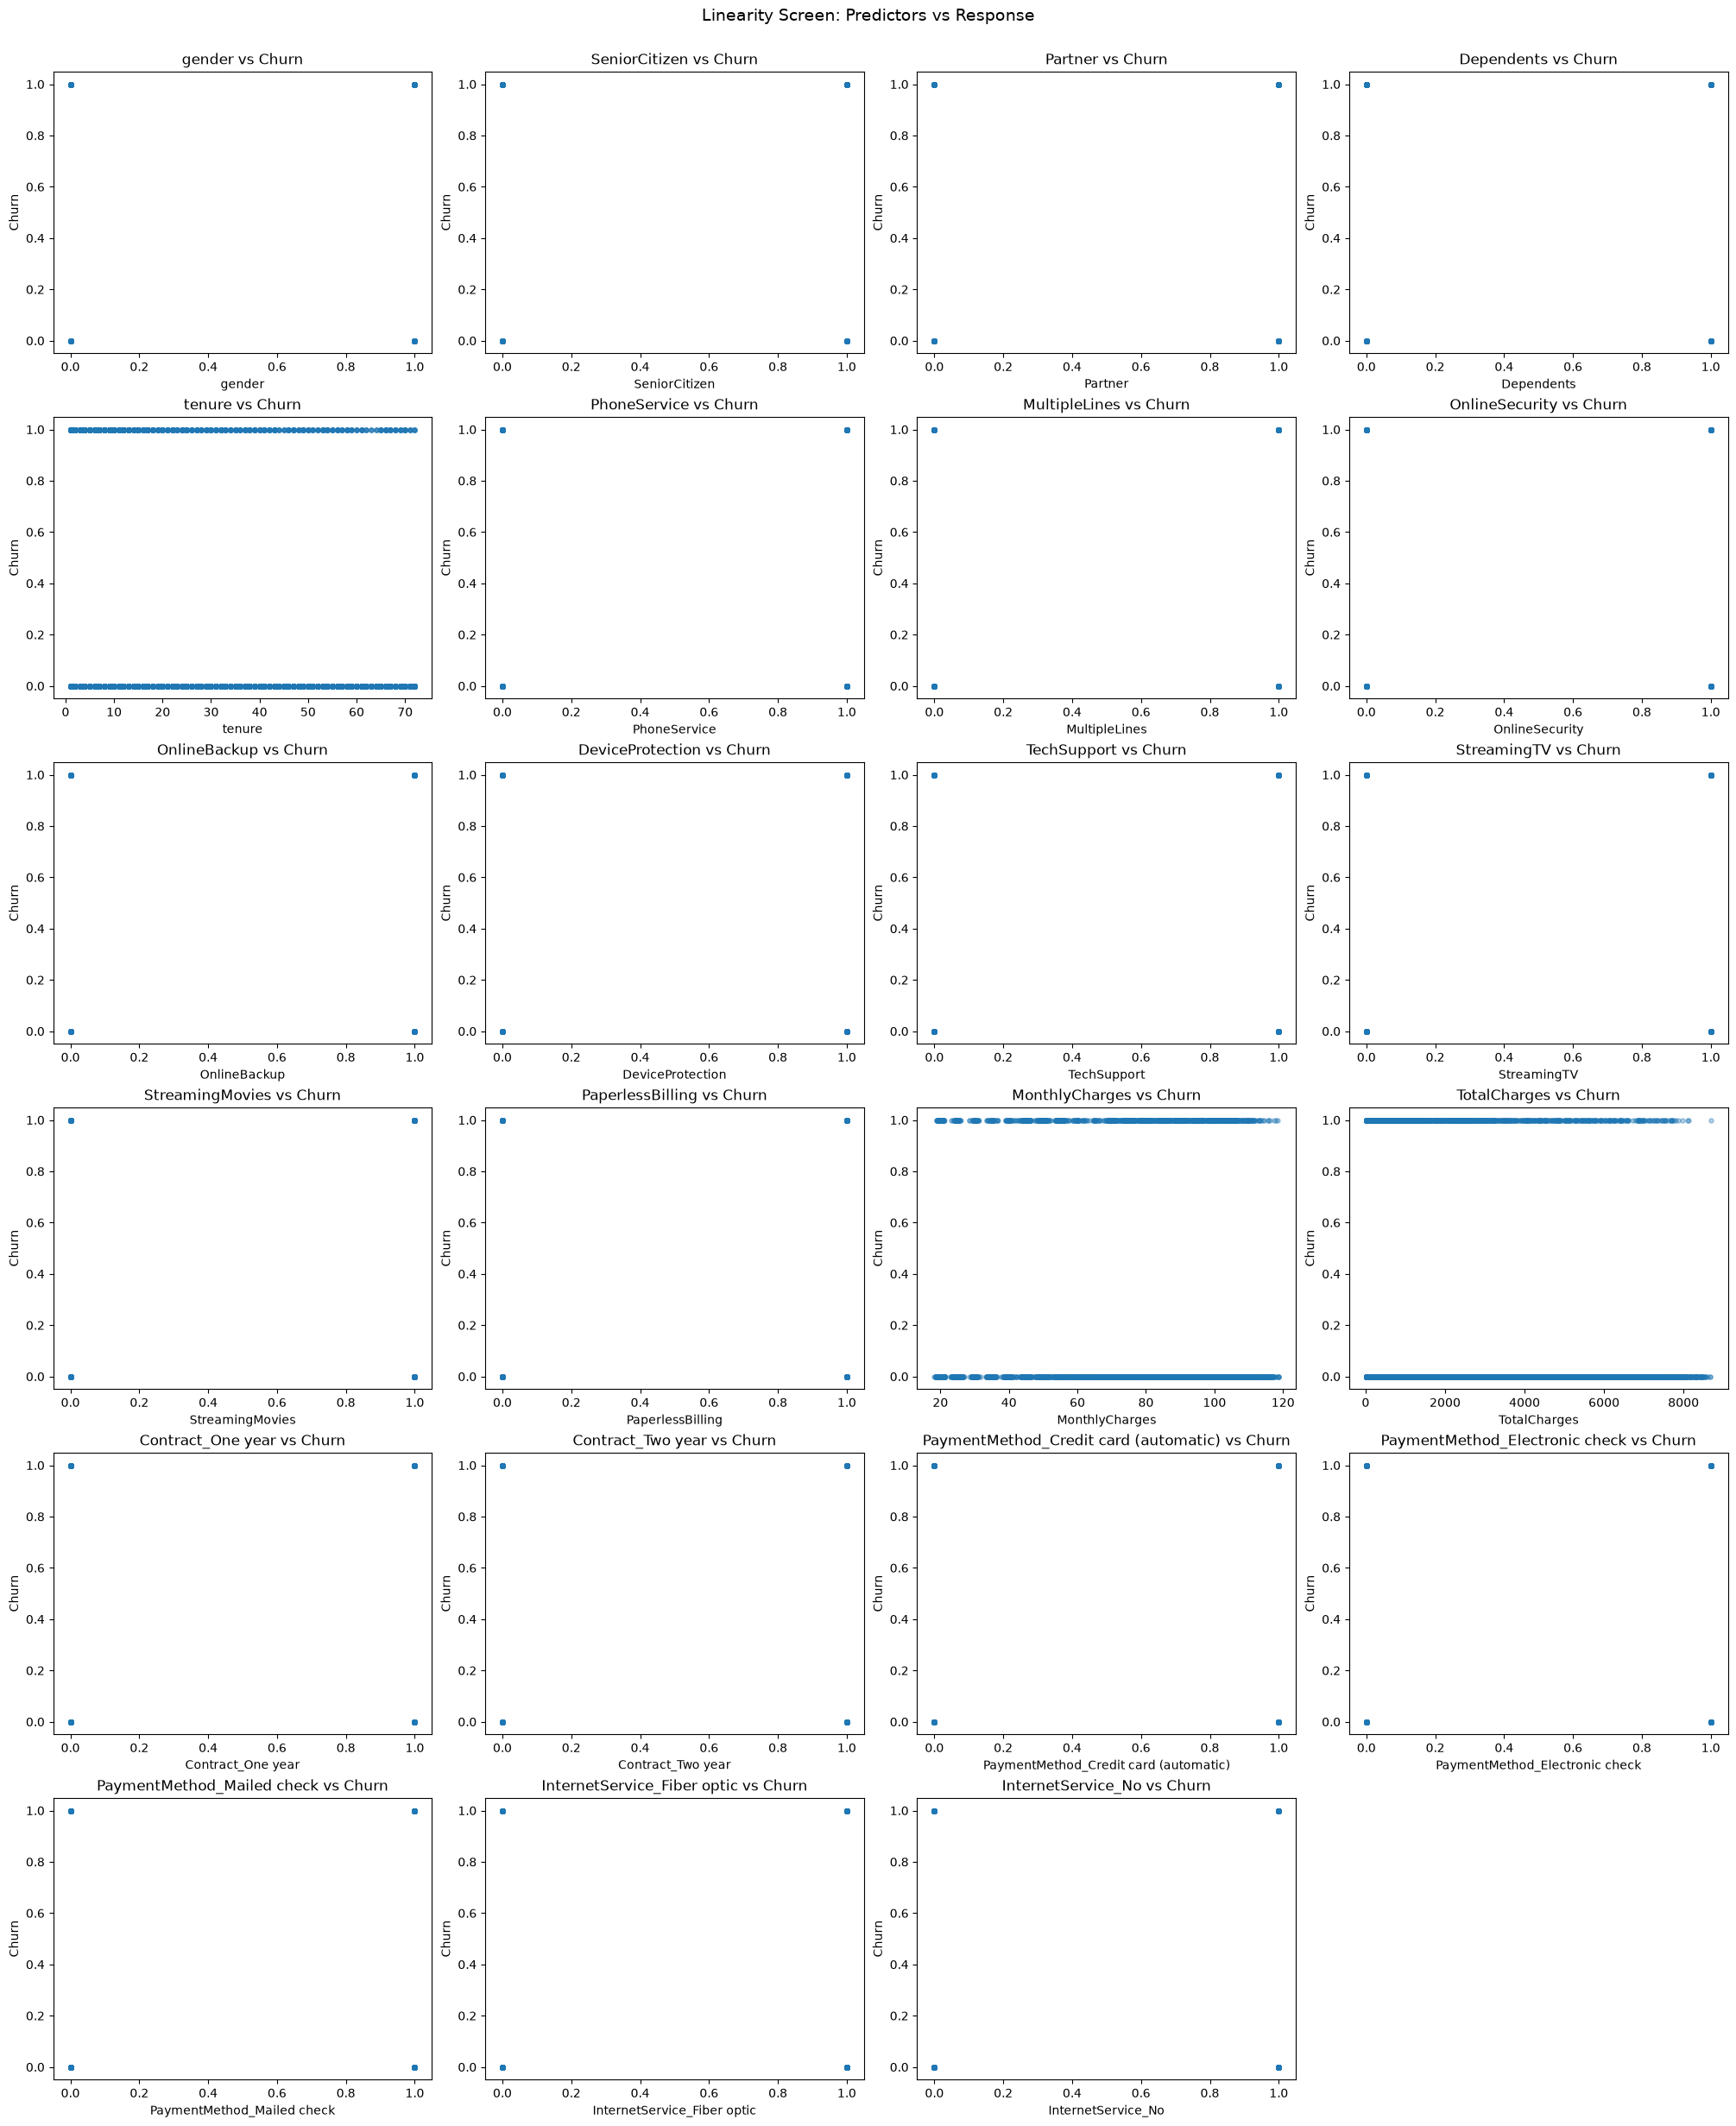

In [36]:
# Linearity check 1: scatter plots of each predictor vs response
linearity_df = df[features + [target]].dropna().copy()

n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(features):
    axes[i].scatter(linearity_df[col], linearity_df[target], alpha=0.35, s=14)
    axes[i].set_title(f"{col} vs {target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Linearity Screen: Predictors vs Response", y=1.02, fontsize=14)
plt.show()

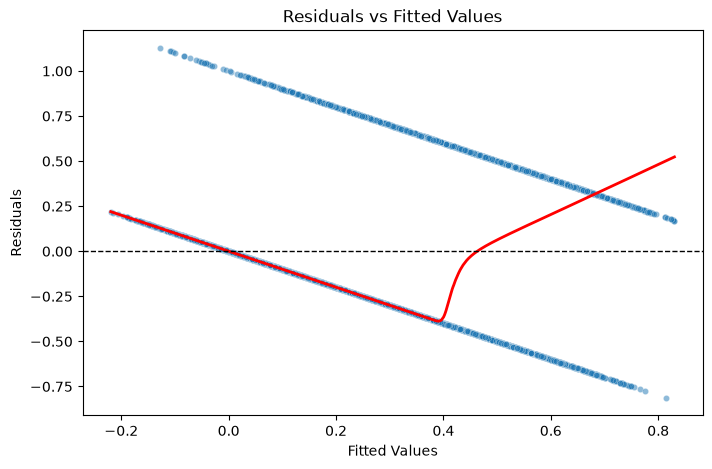

In [37]:
# Fit OLS model for residual diagnostics and RESET test
X = linearity_df[features]
y = linearity_df[target]

X_with_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_with_const).fit()

fitted_vals = ols_model.fittedvalues
residuals = ols_model.resid

# Linearity check 2: residuals vs fitted values
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.5, s=20)
sns.regplot(x=fitted_vals, y=residuals, scatter=False, lowess=True, line_kws={"color": "red", "lw": 2})
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [38]:
# Linearity check 3: Ramsey RESET test
reset_result = linear_reset(ols_model, power=2, use_f=True)
print("Ramsey RESET test")
print(f"F-statistic: {reset_result.fvalue:.4f}")
print(f"p-value: {reset_result.pvalue:.6f}")

if reset_result.pvalue < 0.05:
    print("Interpretation: Evidence of functional form misspecification (possible non-linearity).")
else:
    print("Interpretation: No strong evidence against linear functional form.")

Ramsey RESET test
F-statistic: 206.0555
p-value: 0.000000
Interpretation: Evidence of functional form misspecification (possible non-linearity).


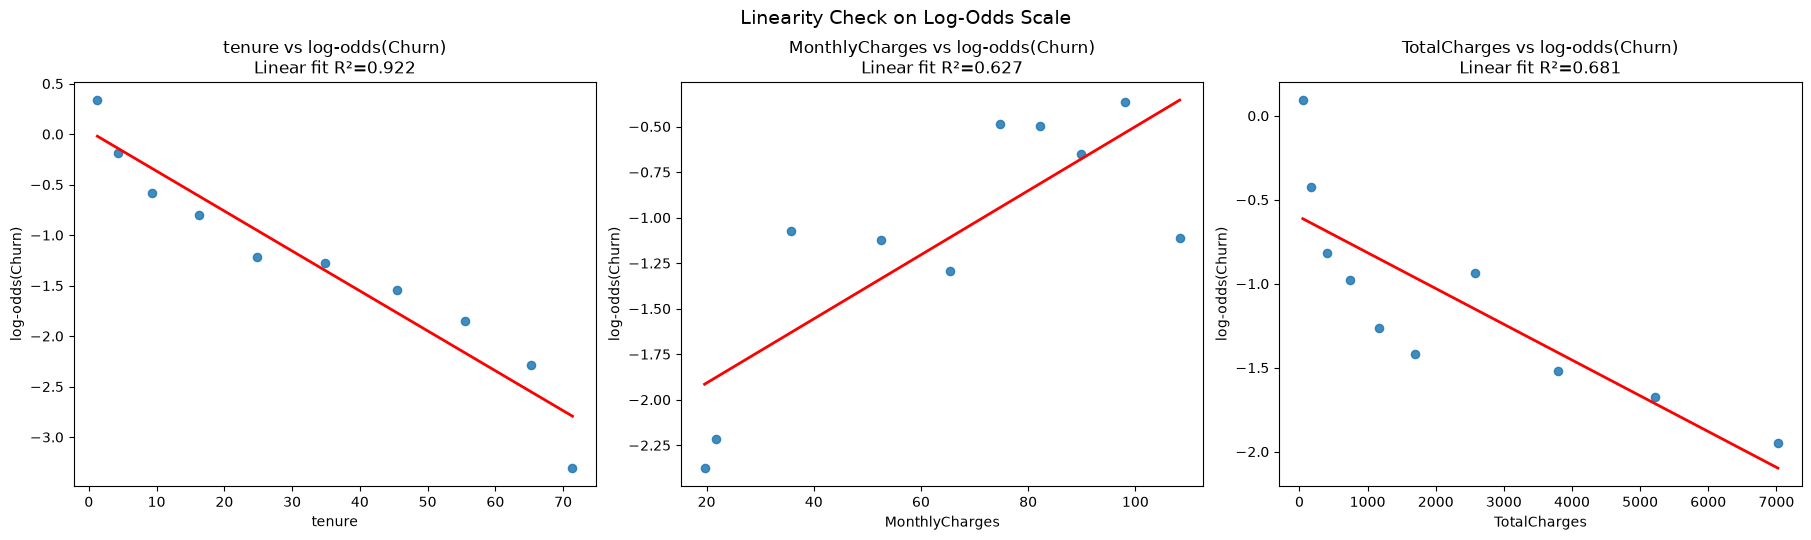

In [ ]:
# Additional linearity check: continuous predictors vs log-odds of churn, since churn is binary
continuous_for_log_odds = ["tenure", "MonthlyCharges", "TotalCharges"]
n_bins = 10
eps = 1e-4

fig, axes = plt.subplots(1, len(continuous_for_log_odds), figsize=(18, 5), constrained_layout=True)

for i, col in enumerate(continuous_for_log_odds):
    tmp = df[[col, "Churn"]].dropna().copy()
    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp = tmp.dropna()

    # Bin predictor and compute churn rate per bin
    tmp["bin"] = pd.qcut(tmp[col], q=n_bins, duplicates="drop")
    grouped = tmp.groupby("bin", observed=False).agg(
        x_mean=(col, "mean"),
        churn_rate=("Churn", "mean")
    ).dropna()

    # Clip rates away from 0 and 1 to avoid infinite log-odds
    grouped["churn_rate_clipped"] = grouped["churn_rate"].clip(eps, 1 - eps)
    grouped["log_odds"] = np.log(grouped["churn_rate_clipped"] / (1 - grouped["churn_rate_clipped"]))

    # Fit a simple line to summarize linear trend
    slope, intercept = np.polyfit(grouped["x_mean"], grouped["log_odds"], 1)
    y_hat = slope * grouped["x_mean"] + intercept
    r2_line = 1 - np.sum((grouped["log_odds"] - y_hat) ** 2) / np.sum((grouped["log_odds"] - grouped["log_odds"].mean()) ** 2)

    axes[i].scatter(grouped["x_mean"], grouped["log_odds"], s=35, alpha=0.85)
    axes[i].plot(grouped["x_mean"], y_hat, color="red", linewidth=2)
    axes[i].set_title(f"{col} vs log-odds(Churn)\nLinear fit R²={r2_line:.3f}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("log-odds(Churn)")

plt.suptitle("Linearity Check on Log-Odds Scale", fontsize=14, y=1.05)
plt.show()

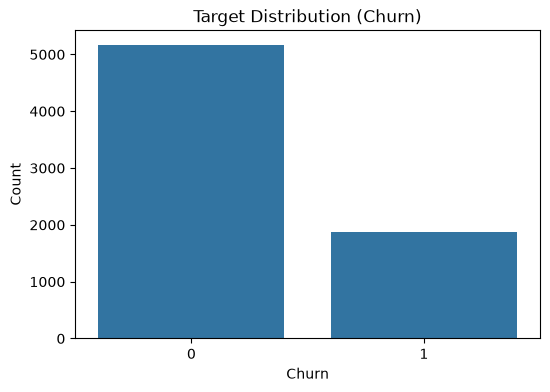

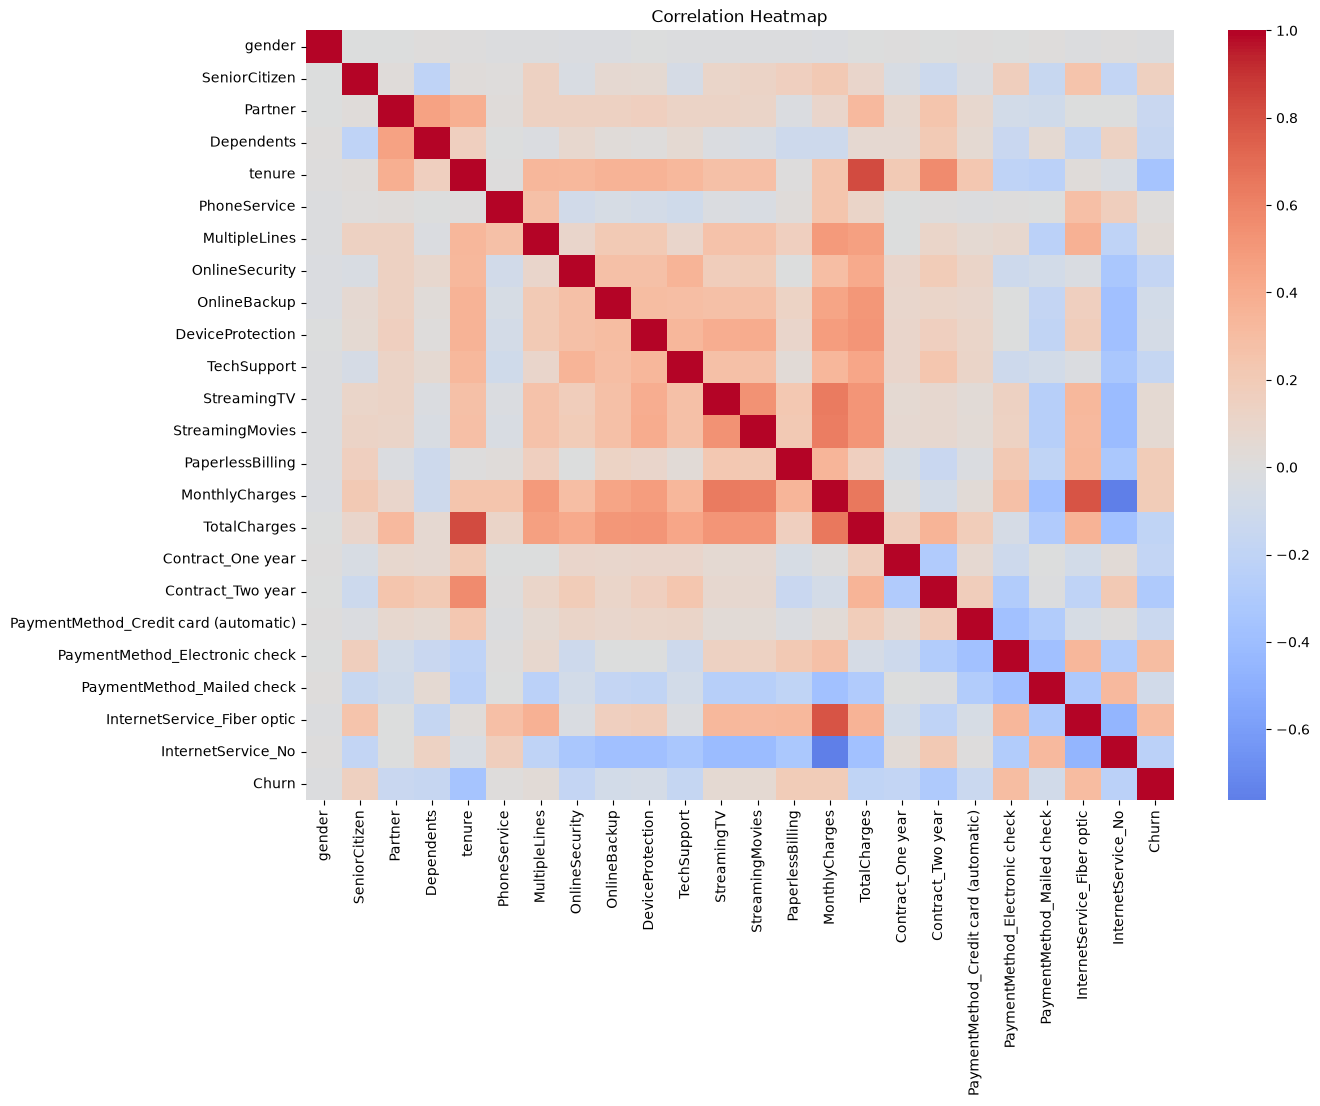

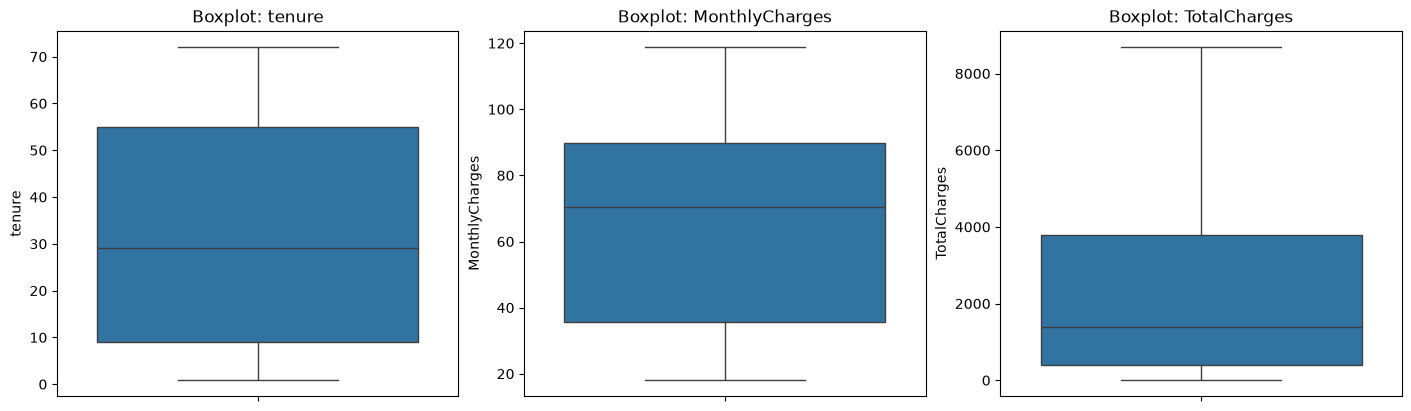

In [39]:
eda_df = df[features + [target]].dropna().copy()

# Target balance (helps contextualize linear fit on a binary outcome)
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=eda_df)
plt.title("Target Distribution (Churn)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Correlation map for numeric predictors and target
corr = eda_df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Outlier screening for key continuous predictors
continuous_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(14, 4), constrained_layout=True)
for i, col in enumerate(continuous_cols):
    sns.boxplot(y=eda_df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")
plt.show()

From above, we see that TotalCharges is highly correlated with MonthlyCharges and Tenure, so we should not include this as a feature in our model, or this would violate the multicollinearity assumption.

## 3. Linear Regression Model Code

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No']
X_full = eda_df[features]
y_full = eda_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred = lin_reg.predict(X_test_scaled)

## 4. Model Performance Evidence

Linear Regression Performance (Test Set)
RMSE: 0.3812
MAE:  0.3102
R^2:  0.2555
Raw Accuracy (no threshold, exact match): 0.0000
Thresholded Accuracy (0.5 cutoff): 0.7982


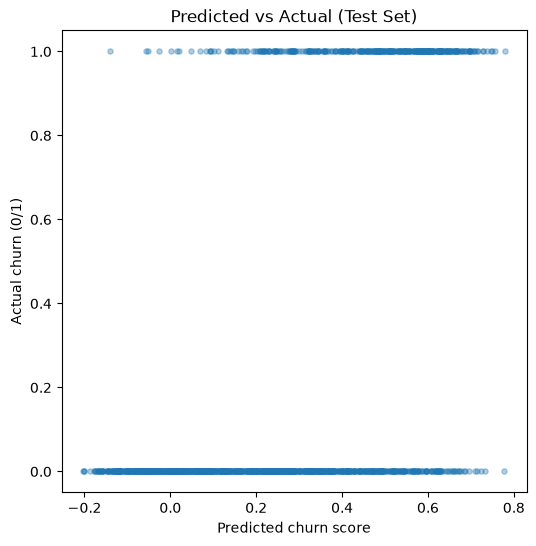

In [47]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance (Test Set)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

# Non-thresholded exact-match accuracy (continuous predictions vs true binary labels)
raw_accuracy = (y_pred == y_test.values).mean()
print(f"Raw Accuracy (no threshold, exact match): {raw_accuracy:.4f}")

y_pred_class = (y_pred >= 0.5).astype(int)
accuracy = (y_pred_class == y_test.values).mean()
print(f"Thresholded Accuracy (0.5 cutoff): {accuracy:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_pred, y_test, alpha=0.35, s=14)
plt.xlabel("Predicted churn score")
plt.ylabel("Actual churn (0/1)")
plt.title("Predicted vs Actual (Test Set)")
plt.show()

The linear regression model has a RMSE of 0.3801 and the thresholded accuracy is 0.7953 if we consider a threshold of 0.5. If we use raw accuracy, not using any threshold then the accuracy is 0 because it is checking linear regression continuous responses against correct churn values which are binary.

## 5. Coefficient Interpretation

In [45]:
coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

display(coef_table.head(12))

,feature,coefficient
14,MonthlyCharges,-0.210488
20,InternetService_Fiber optic,0.154850
21,InternetService_No,-0.124068
4,tenure,-0.109244
11,StreamingTV,0.050716
12,StreamingMovies,0.050530
15,Contract_One year,-0.047593
6,MultipleLines,0.040312
18,PaymentMethod_Electronic check,0.038023
16,Contract_Two year,-0.031730


## 6. Limitation of Using Linear Regression for Churn

In our problem, churn is a binary variable (0 or 1), but linear regression predicts any continous values such as below 0 or above 1, so the output is not the natural response for our problem. The predictions can fall outside 0 to 1. Additionally, because the outcome is binary, the residuals are not normally distributed so this assumption is violated. 